In [2]:
import torch
import pandas as pd
from fastai.vision.all import *

In [6]:
import numpy as np

def load_glove_model(File):
    print("Loading Glove Model")
    glove_model = {}
    with open(File,'r') as f:
        for line in f:
            split_line = line.split()
            word = split_line[0]
            embedding = np.array(split_line[1:], dtype=np.float64)
            glove_model[word] = embedding
    print(f"{len(glove_model)} words loaded!")
    return glove_model

glove_model = load_glove_model('glove.6B.50d.txt')

Loading Glove Model
400000 words loaded!


In [8]:
# 首先得到所有单词的词向量表示
metadata_glove = torch.zeros(12,50)
metadata_glove[0] = torch.tensor(glove_model['focus'])
metadata_glove[1] = torch.tensor(glove_model['eyes'])
metadata_glove[2] = torch.tensor(glove_model['face'])
metadata_glove[3] = torch.tensor(glove_model['near'])
metadata_glove[4] = torch.tensor(glove_model['action'])
metadata_glove[5] = torch.tensor(glove_model['accessory'])
metadata_glove[6] = torch.tensor(glove_model['group'])
metadata_glove[7] = torch.tensor(glove_model['collage'])
metadata_glove[8] = torch.tensor(glove_model['human'])
metadata_glove[9] = torch.tensor(glove_model['occlusion'])
metadata_glove[10] = torch.tensor(glove_model['info'])
metadata_glove[11] = torch.tensor(glove_model['blur'])

<Axes: >

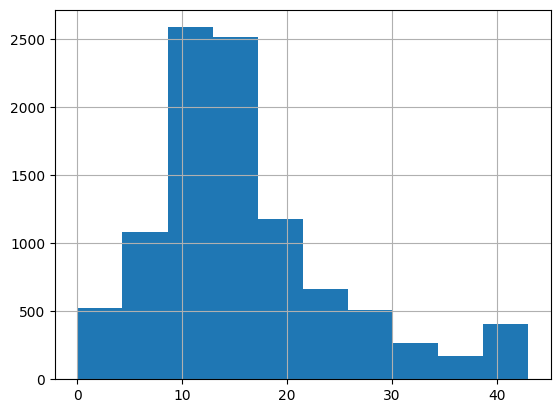

In [10]:
BATCH_SIZE = 40
seed=999
set_seed(seed, reproducible=True)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True

train_df = pd.read_csv('train.csv')
dataset_path = Path('.')
train_df['path'] = train_df['Id'].map(lambda x:str(dataset_path/'train'/x)+'.jpg')
train_df = train_df.drop(columns=['Id'])
train_df = train_df.sample(frac=1).reset_index(drop=True) #shuffle dataframe
train_df['norm_score'] = train_df['Pawpularity']/100
train_df['norm_score']
#Sturges' rule
num_bins = int(np.floor(1+(3.3)*(np.log2(len(train_df)))))
# num_bins
train_df['bins'] = pd.cut(train_df['norm_score'], bins=num_bins, labels=False)
train_df['bins'].hist()



<Axes: xlabel='fold'>

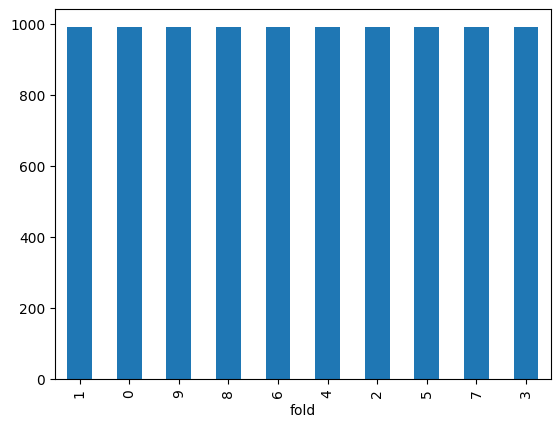

In [12]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

train_df['fold'] = -1


N_FOLDS = 10
strat_kfold = StratifiedKFold(n_splits=N_FOLDS, random_state=seed, shuffle=True)
for i, (_, train_index) in enumerate(strat_kfold.split(train_df.index, train_df['bins'])):
    train_df.iloc[train_index, -1] = i
    
train_df['fold'] = train_df['fold'].astype('int')

train_df.fold.value_counts().plot.bar()

In [14]:
def petfinder_rmse(input,target):
    return 100*torch.sqrt(F.mse_loss(F.sigmoid(input.flatten()), target))

In [16]:
from fastai.tabular.all import *
# 下面这个就是图片的dataloader，做一个tabular的模型
def get_data_meta(fold):
#     train_df_no_val = train_df.query(f'fold != {fold}')
#     train_df_val = train_df.query(f'fold == {fold}')
    
#     train_df_bal = pd.concat([train_df_no_val,train_df_val.sample(frac=1).reset_index(drop=True)])
    train_df_f = train_df.copy()
    # add is_valid for validation fold
    train_df_f['is_valid'] = (train_df_f['fold'] == fold)

    dls = TabularDataLoaders.from_df(train_df_f, 
                                      valid_col='is_valid',
                                      path = '../input/petfinder-pawpularity-score',
                                      y_names="norm_score", 
                                      valid_pct=0.2,
                                      seed=seed, #seed
                                      bs=BATCH_SIZE, 
                                      num_workers=8, 
                                      y_block=RegressionBlock,
                                      cont_names = ['Subject Focus', 'Eyes', 'Face', 'Near', 'Action', 'Accessory',\
                                                    'Group', 'Collage', 'Human', 'Occlusion', 'Info', 'Blur']
                                    )
    
    
#     dls = ImageDataLoaders.from_df(train_df_f, #pass in train DataFrame
# #                                valid_pct=0.2, #80-20 train-validation random split
#                                valid_col='is_valid', #
#                                seed=999, #seed
#                                fn_col='path', #filename/path is in the second column of the DataFrame
#                                label_col='norm_score', #label is in the first column of the DataFrame
#                                y_block=RegressionBlock, #The type of target
#                                bs=BATCH_SIZE, #pass in batch size
#                                num_workers=8,
#                                item_tfms=Resize(Image_size, resamples=(Image.BICUBIC, Image.NEAREST)), #pass in item_tfms
#                                batch_tfms=setup_aug_tfms([Brightness(), Contrast(), Hue(), Saturation()]))    #pass in batch_tfms
    
    return dls

In [18]:
dls = get_data_meta(1)

In [20]:
# # metadata 放后面
# class meta_model(Module):
#     def __init__(self, pretrained=True):
#         # self.model = create_model('swin_large_patch4_window7_224', pretrained=True, num_classes=1)
#         # self.model.head = nn.Linear(self.model.head.in_features, 128) # 输入特征
#         super().__init__()
#         self.dropout = nn.Dropout(0.1) # dropout率
#         self.dense1 = nn.Linear(134, 128) # 全连接层 128+6,6是超参数经过了MLP的映射
#         self.dense2 = nn.Linear(128, 1) # 全连接层，最后弄成softmax
#         self.dense1_meta = nn.Linear(12, 10) # 全连接层
#         self.dense2_meta = nn.Linear(10, 1) # 全连接层
#         # 由于是relu，加上kaiminghe的初始化
#         torch.nn.init.normal_(self.dense1_meta.weight, mean=0, std=np.sqrt(2/12))
#         torch.nn.init.normal_(self.dense2_meta.weight, mean=0, std=np.sqrt(2/10))
#         torch.nn.init.normal_(self.dense1.weight, mean=0, std=np.sqrt(2/134))
#         torch.nn.init.normal_(self.dense2.weight, mean=0, std=np.sqrt(2/128))
#         torch.nn.init.constant_(self.dense1_meta.bias, 0.)
#         torch.nn.init.constant_(self.dense2_meta.bias, 0.)
#         torch.nn.init.constant_(self.dense1.bias, 0.)
#         torch.nn.init.constant_(self.dense2.bias, 0.)
#         self.step_scheduler_after = "epoch"
#     def forward(self, features):
#         # embedding = metadata_glove*features # 获得embedding结果，如果是0，就是zeros
# #         x = self.dense1(features)
# #         meta_MLP = self.dense1_meta(features)
# #         meta_MLP = nn.functional.relu(meta_MLP)
# #         meta_MLP = self.dense2_meta(meta_MLP)
# #         meta_MLP = nn.functional.relu(meta_MLP)
# #         x = torch.cat([x, meta_MLP], dim=1) # 将超数据与文字数据通过全连接层的隐藏层进行了链接
#         x = self.dense1_meta(features) # 全连接进行输出
#         x = nn.functional.relu(x)
#         x = self.dense2_meta(x)
#         return x

In [22]:
import torch.nn as nn
import torch
# class PawpularModel_meta(nn.Module):
#     def __init__(self, model_name='swin_large_patch4_window7_224', num_classes=[12,1],
#                  n_meta_dim=[256, 128], pretrained=True):
#         super().__init__()
#         out_dim=num_classes[1] # 输出1
#         n_meta_features=num_classes[0] # meta维度 17
#         self.n_meta_features = n_meta_features
#         # self.enet = create_model(model_name, pretrained=True, in_chans=3) # 这里没有标准化，输出是维度是1536
#         self.dropouts = nn.ModuleList([
#             nn.Dropout(0.5) for _ in range(5)
#         ])
#         # in_ch = self.enet.head.in_features # 768*2=1536维度
#         if n_meta_features > 0:
#             self.meta = nn.Sequential(
#                 nn.Linear(n_meta_features, n_meta_dim[0]), # 17 到 256维度
#                 nn.BatchNorm1d(n_meta_dim[0]), # norm操作 维度256
#                 nn.SiLU(), # 激活函数
#                 nn.Dropout(p=0.3), # drop0.3
#                 nn.Linear(n_meta_dim[0], n_meta_dim[1]), # 256 到 128 维度
#                 nn.BatchNorm1d(n_meta_dim[1]), # norm操作 维度128
#                 nn.SiLU(), # 激活函数
#             )
            
#             #in_ch += n_meta_dim[1] # 128+768*2维度，将meta拼接到前面
#             # print('in_ch is ' + str(in_ch))
#         self.myfc = nn.Linear(n_meta_dim[1], out_dim) # 1664到1
#         # self.enet.head = nn.Identity()

# #     def extract(self, x):
# #         x = self.enet(x) # 输出768*2
# #         #print(x.shape)
# #         return x

#     def forward(self, ff, features):
#         #print(features)
#         #print(ff)
#         x_meta = self.meta(features) # meta输入，得到128维度
#         out = self.myfc(x_meta)
        
# #         x = self.extract(image).squeeze(-1).squeeze(-1) # 用swin输出得到1536
# #         #print(x.shape) #1536=768*2
# #         if self.n_meta_features > 0:
# #             x_meta = self.meta(features) # meta输入，得到128维度
# #             x = torch.cat((x, x_meta), dim=1) # 将meta和swin拼接起来 128+1536 = 1664
# #         for i, dropout in enumerate(self.dropouts):
# #             if i == 0:
# #                 out = self.myfc(dropout(x))
# #             else:
# #                 out += self.myfc(dropout(x)) # 相当于将1664同时经过了5个全连接，然后求和，这里是串行的程序，可以修改为并行，将输出设定为5维，然后再从5维到1维
# #         out /= len(self.dropouts) # 求一个平均，没什么意义，我将1664到1维的权重学习为原来的五分之一就可以达到一样的效果
#         return out
class PawpularModel_meta(nn.Module):
    def __init__(self, model_name='swin_large_patch4_window7_224', num_classes=[12,1], reduction_dim = 5,
                 n_meta_dim=[256, 128], pretrained=True):
        super().__init__()
        out_dim=num_classes[1] # 输出1
        n_meta_features=num_classes[0] # meta维度 17
        self.reduce_d = nn.Linear(50, reduction_dim) # embedding降维到5 
        self.meta_order1 = nn.Linear(432+60, 100)
        self.meta_order2 = nn.Linear(100, 10)
        self.meta_order3 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.5)




        # self.n_meta_features = n_meta_features
        # # self.enet = create_model(model_name, pretrained=True, in_chans=3) # 这里没有标准化，输出是维度是1536
        # self.dropouts = nn.ModuleList([
        #     nn.Dropout(0.5) for _ in range(5)
        # ])
        # # in_ch = self.enet.head.in_features # 768*2=1536维度
        # if n_meta_features > 0:
        #     self.meta = nn.Sequential(
        #         nn.Linear(n_meta_features, n_meta_dim[0]), # 17 到 256维度
        #         nn.BatchNorm1d(n_meta_dim[0]), # norm操作 维度256
        #         nn.SiLU(), # 激活函数
        #         nn.Dropout(p=0.3), # drop0.3
        #         nn.Linear(n_meta_dim[0], n_meta_dim[1]), # 256 到 128 维度
        #         nn.BatchNorm1d(n_meta_dim[1]), # norm操作 维度128
        #         nn.SiLU(), # 激活函数
        #     )
            
        #     #in_ch += n_meta_dim[1] # 128+768*2维度，将meta拼接到前面
        #     # print('in_ch is ' + str(in_ch))
        # self.myfc = nn.Linear(n_meta_dim[1], out_dim) # 1664到1
        # self.enet.head = nn.Identity()

#     def extract(self, x):
#         x = self.enet(x) # 输出768*2
#         #print(x.shape)
#         return x

    def forward(self, ff, features):
        #print(features)
        #print(ff)
        embed = torch.zeros(BATCH_SIZE, *metadata_glove.shape).cuda()
        for idx, eve_feature in enumerate(features):
            embed[idx] = (eve_feature*metadata_glove.T).T
        embed_reduce = self.reduce_d(embed) # 获得了降维的tensor
        embed_norm = torch.norm(embed_reduce, dim=2)
        embed_norm = embed_norm.unsqueeze(2)
        embed_reduce = embed_reduce/embed_norm # 获得归一化的降维的向量
        #embed_reduce = embed
        dot_result = torch.bmm(embed_reduce, embed_reduce.permute(0,2,1)).reshape(BATCH_SIZE, -1)
        dot_tanh = torch.tanh(dot_result) 
        dot_relu = torch.relu(dot_result) 
        dot_sig = torch.sigmoid(dot_result) 
        
        hig_order = torch.cat([dot_tanh, dot_relu, dot_sig], 1)
        all_order = torch.cat([embed_reduce.reshape(BATCH_SIZE, -1), hig_order], 1)
        
        out1 = self.meta_order1(self.dropout(all_order))
        out2 = self.meta_order2(self.dropout(out1))
        out3 = self.meta_order3(self.dropout(out2))
#         x = self.extract(image).squeeze(-1).squeeze(-1) # 用swin输出得到1536
#         #print(x.shape) #1536=768*2
#         if self.n_meta_features > 0:
#             x_meta = self.meta(features) # meta输入，得到128维度
#             x = torch.cat((x, x_meta), dim=1) # 将meta和swin拼接起来 128+1536 = 1664
#         for i, dropout in enumerate(self.dropouts):
#             if i == 0:
#                 out = self.myfc(dropout(x))
#             else:
#                 out += self.myfc(dropout(x)) # 相当于将1664同时经过了5个全连接，然后求和，这里是串行的程序，可以修改为并行，将输出设定为5维，然后再从5维到1维
#         out /= len(self.dropouts) # 求一个平均，没什么意义，我将1664到1维的权重学习为原来的五分之一就可以达到一样的效果
        return out3

In [24]:
def get_learner_meta(fold_num):
    data = get_data_meta(fold_num)
    model = PawpularModel_meta()
#     if meta:
#         print("data.c:", data.c)
#         model = PawpularModel(Model_name, num_classes=data.c) # 如果有超参数，就用上面写好的模型
#     else:    
#         model = create_model(Model_name, pretrained=True, num_classes=data.c)
    learn = Learner(data, model, loss_func = petfinder_rmse, metrics=petfinder_rmse) # 默认就是全连接神经网络
    #learn = tabular_learner(data,  loss_func = petfinder_rmse, metrics=petfinder_rmse) # 默认就是全连接神经网络
    # learn = Learner(data, model, loss_func=BCEWithLogitsLossFlat(), metrics=petfinder_rmse).to_fp16()
    
    return learn

In [26]:
# 下面开始弄图片

In [28]:
!pip install ImageHash

In [29]:
!pip install --upgrade timm

In [31]:
!pip install albumentations

In [33]:
import sys
from PIL import Image
import imagehash
sys.path.append('../input/timm-pytorch-image-models/pytorch-image-models-master')
from timm import create_model
from timm.data.mixup import Mixup
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import albumentations
tqdm.pandas()

/Users/hanhan/opt/anaconda3/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [35]:
from fastai.vision.all import *

In [38]:
def get_data_pic(fold):
#     train_df_no_val = train_df.query(f'fold != {fold}')
#     train_df_val = train_df.query(f'fold == {fold}')
    
#     train_df_bal = pd.concat([train_df_no_val,train_df_val.sample(frac=1).reset_index(drop=True)])
    train_df_f = train_df.copy()
    # add is_valid for validation fold
    train_df_f['is_valid'] = (train_df_f['fold'] == fold)
    
    dls = ImageDataLoaders.from_df(train_df_f, #pass in train DataFrame
#                                valid_pct=0.2, #80-20 train-validation random split
                               valid_col='is_valid', #
                               seed=seed, #seed
                               fn_col='path', #filename/path is in the second column of the DataFrame
                               label_col='norm_score', #label is in the first column of the DataFrame
                               y_block=RegressionBlock, #The type of target
                               bs=BATCH_SIZE, #pass in batch size
                               num_workers=8,
                               item_tfms=Resize(224), #pass in item_tfms
                               #batch_tfms=setup_aug_tfms([RandomErasing(),  Rotate(),   Flip()]))
                               batch_tfms=setup_aug_tfms([RandomErasing(), Rotate(),  Zoom(), Brightness(), Flip(), Contrast(), Saturation()])) #pass in batch_tfms
    
    return dls


In [40]:
def get_learner_meta(fold_num):
    data = get_data_meta(fold_num)
    
    class MetaWrapper(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base = base_model
        def forward(self, xb):
            # fastai TabularDataLoaders provide (conts, cats)
            if isinstance(xb, tuple):
                xb = xb[0]
            # feed the same tensor twice to match the model’s two-input signature
            return self.base(xb, xb)

    model = MetaWrapper(PawpularModel_meta())

    learn = Learner(
        data,
        model,
        loss_func=MSELossFlat(),            # simpler, stable for regression
        metrics=AccumMetric(func=petfinder_rmse)
    )

    return learn


In [42]:
test_df = pd.read_csv('test.csv')
test_df['Pawpularity'] = [1]*len(test_df)
test_df['path'] = test_df['Id'].map(lambda x:str(dataset_path/'test'/x)+'.jpg')
test_df = test_df.drop(columns=['Id'])

In [55]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# 12 meta features used in the parent paper
meta_cols = [
    'Subject Focus', 'Eyes', 'Face', 'Near', 'Action', 'Accessory',
    'Group', 'Collage', 'Human', 'Occlusion', 'Info', 'Blur'
]

# X: meta features, y: normalized target (0–1)
X_train = train_df[meta_cols].values
y_train = train_df['norm_score'].values   # they defined this earlier as Pawpularity / 100

X_test  = test_df[meta_cols].values

# Simple, robust meta model
rf_meta = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    n_jobs=-1,
    random_state=seed
)

rf_meta.fit(X_train, y_train)

# Predictions on test set (still in 0–1 range)
preds_meta_only = rf_meta.predict(X_test)


In [53]:
sample_df = pd.read_csv(dataset_path/'sample_submission.csv')

# Convert back to 0–100 range and clip just in case
preds = np.clip(preds_meta_only * 100, 0, 100)

sample_df['Pawpularity'] = preds
sample_df.to_csv('submission_meta_only.csv', index=False)

sample_df.head()

,Id,Pawpularity
0,4128bae22183829d2b5fea10effdb0c3,35.413594
1,43a2262d7738e3d420d453815151079e,32.848240
2,4e429cead1848a298432a0acad014c9d,45.017388
3,80bc3ccafcc51b66303c2c263aa38486,34.165131
4,8f49844c382931444e68dffbe20228f4,26.849068
